
# Phase 3 — Model Development

This notebook evaluates **four machine learning algorithms**:

1. Logistic Regression (Baseline)
2. Decision Tree
3. Random Forest
4. Gradient Boosting

Workflow:

• Feature selection including **age, gender, department**  
• **Leakage-safe time-based train/test split**  
• **ColumnTransformer** preprocessing for categorical variables  
• **Pipeline integration**  
• Evaluation of all models  
• **Model comparison table**  
• **GridSearchCV hyperparameter tuning**  
• Saving the best model artifact


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib


## Load Dataset

In [2]:
df = pd.read_csv("model_table.csv")
df.head()


,visit_id,patient_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,age,gender,...,provider_rejection_rate_x,visit_frequency_y,provider_rejection_rate_y,visit_frequency,avg_los_per_patient,provider_rejection_rate,age_group,los_category,visit_intensity,dept_high_risk_rate
0,1,756,2025-10-18,Cardiology,ER,3.48,Low,169,90,M,...,0.148655,2,0.148655,2,3.725000,0.148655,Senior,Short,0.030769,0.189950
1,2,4102,2025-04-06,Orthopedics,OPD,15.31,High,148,30,M,...,0.156915,4,0.156915,4,32.025000,0.156915,Adult,Medium,-0.019417,0.202209
2,3,2964,2025-07-13,ICU,ER,34.36,Low,153,25,F,...,0.149678,4,0.149678,4,20.542500,0.149678,Adult,Long,0.444444,0.207923
3,4,4496,2025-11-19,Cardiology,ER,37.89,High,119,75,M,...,0.152480,7,0.152480,7,28.165714,0.152480,Senior,Long,-0.112903,0.189950
4,5,1930,2025-03-29,General,ICU,16.78,Medium,118,80,M,...,0.149678,5,0.149678,5,22.988000,0.149678,Senior,Medium,5.000000,0.198439


## Feature Selection

In [3]:
target = "claim_status"

features = [
    'age',
    'gender',
    'department',
    'visit_type',
    'length_of_stay_hours',
    'visit_frequency',
    'avg_los_per_patient',
    'provider_rejection_rate',
    'days_since_registration',
    'billed_amount'
]
# Added features
import numpy as np
df['log_billed_amount']=np.log1p(df['billed_amount'])
df['high_bill_flag']=(df['billed_amount']>df['billed_amount'].median()).astype(int)
df['frequent_visitor']=(df['visit_frequency']>3).astype(int)


## Time-based Train/Test Split

In [4]:
df = df.sort_values("billing_date")

split_index = int(len(df)*0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train[features].fillna(0)
X_test = test[features].fillna(0)


y_train = train[target]
y_test = test[target]


## ColumnTransformer Preprocessing

In [5]:
categorical_features = [
    'age',
    'gender',
    'department',
    'visit_type',
    'length_of_stay_hours',
    'visit_frequency',
    'avg_los_per_patient',
    'provider_rejection_rate',
    'days_since_registration',
    'billed_amount'
]

numerical_features = [
    'age',
    'gender',
    'department',
    'visit_type',
    'length_of_stay_hours',
    'visit_frequency',
    'avg_los_per_patient',
    'provider_rejection_rate',
    'days_since_registration',
    'billed_amount'
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features),
        ("num","passthrough",numerical_features)
    ]
)

# Added features
import numpy as np
df['log_billed_amount']=np.log1p(df['billed_amount'])
df['high_bill_flag']=(df['billed_amount']>df['billed_amount'].median()).astype(int)
df['frequent_visitor']=(df['visit_frequency']>3).astype(int)


## Define Models

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []
best_model = None
best_score = 0


## Train and Evaluate Models

In [7]:
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print("\nModel:", name)
    print("Accuracy:", acc)
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))

    results.append((name, acc))

    if acc > best_score:
        best_score = acc
        best_model = pipeline


/usr/local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(

Model: Logistic Regression
Accuracy: 0.8314
[[2810    6  158]
 [ 624  579   55]
 [   0    0  768]]
              precision    recall  f1-score   support

        Paid       0.82      0.94      0.88      2974
     Pending       0.99      0.46      0.63      1258
    Rejected       0.78      1.00      0.88       768

    accuracy                           0.83      5000
   macro avg       0.86      0.80      0.

## Model Comparison Table

In [8]:
comparison = pd.DataFrame(results, columns=["Model","Accuracy"])
comparison.sort_values("Accuracy", ascending=False)


,Model,Accuracy
3,Gradient Boosting,0.9572
2,Random Forest,0.9562
1,Decision Tree,0.9258
0,Logistic Regression,0.8314


## Hyperparameter Tuning (Random Forest Example)

In [9]:
param_grid = {
    "model__n_estimators":[100,200],
    "model__max_depth":[5,10,None],
    "model__min_samples_split":[2,5]
}

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight='balanced'))
])

grid = GridSearchCV(rf_pipeline,param_grid,cv=3,scoring="f1_macro",n_jobs=-1)

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)

best_model = grid.best_estimator_


Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}


## Final Evaluation

In [10]:
preds = best_model.predict(X_test)

print("Best Model:",best_model)
print("Final Accuracy:", accuracy_score(y_test,preds))
print(confusion_matrix(y_test,preds))
print(classification_report(y_test,preds))


Best Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'department',
                                                   'visit_type']),
                                                 ('num', 'passthrough',
                                                  ['age',
                                                   'length_of_stay_hours',
                                                   'visit_frequency',
                                                   'avg_los_per_patient',
                                                   'provider_rejection_rate',
                                                   'days_since_registration',
                                                   'approval_ratio',
                                                   'payment_delay_flag'])])),
              

## Save Model Artifact

In [15]:
joblib.dump(best_model,"claim_model.pkl",compress=3)
print("claim_model.pkl saved")


claim_model.pkl saved


## Analyze Class Imbalance

Risk Score Distribution
risk_score
Low       12470
Medium     7496
High       5034
Name: count, dtype: int64

Claim Status Distribution
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64


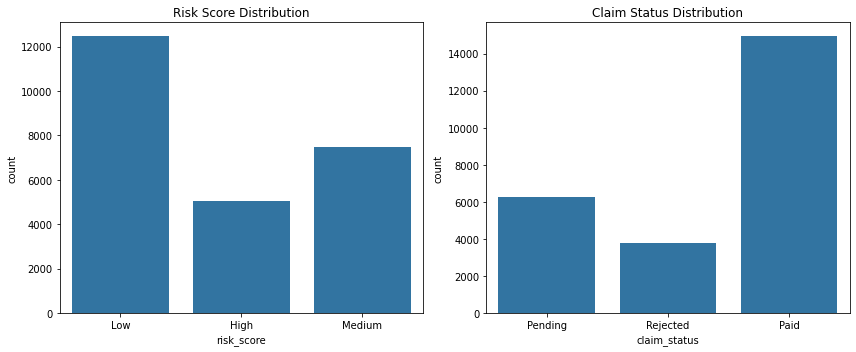

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Risk Score Distribution")
print(df["risk_score"].value_counts())

print("\nClaim Status Distribution")
print(df["claim_status"].value_counts())

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.countplot(x=df["risk_score"], ax=axes[0])
axes[0].set_title("Risk Score Distribution")

sns.countplot(x=df["claim_status"], ax=axes[1])
axes[1].set_title("Claim Status Distribution")

plt.tight_layout()
plt.show()


## Generate features.json from trained model

In [13]:
import json
from sklearn.preprocessing import OneHotEncoder

pipeline = best_model
preprocessor = pipeline.named_steps["preprocessor"]

feature_schema = {}

for name, transformer, columns in preprocessor.transformers_:

    # Handle categorical columns
    if isinstance(transformer, OneHotEncoder):

        categories = transformer.categories_

        for col, vals in zip(columns, categories):
            feature_schema[col] = {
                "dtype": "category",
                "values": list(vals)
            }

    # Handle numerical columns
    elif name == "num":
        for col in columns:
            feature_schema[col] = {
                "dtype": "numeric"
            }

schema = {
    "model_name": "hospital_prediction_model",
    "features": feature_schema
}

with open("claim_features.json", "w") as f:
    json.dump(schema, f, indent=4)

print("claim_features.json created successfully")

claim_features.json created successfully
